# Notebook 05: Transfer Learning — ResNet-50

**Student:** Okidi Patrovas Gabriel | 2025/HD07/26018U  
**Institution:** Makerere University, Kampala, Uganda  
**Course:** MSB7216 — Deep Learning for Health Data

## Overview
This notebook fine-tunes ResNet-50 pretrained on ImageNet on the LC25000 dataset. ResNet-50 is a deeper residual network with 50 layers and skip connections that help gradients flow during training. We use the same two-phase training strategy as Notebook 04 for a fair comparison.

## Objectives
1. Load the same splits used in Notebooks 03 and 04.
2. Load images from local Colab storage for fast GPU training.
3. Build ResNet-50 with a replaced fully connected head.
4. Train in two phases: head-only warmup, then full fine-tuning.
5. Plot training and validation curves.
6. Evaluate on the test set with all metrics.
7. Plot confusion matrix and ROC curves.
8. Compare results against the baseline and EfficientNet-B0.
9. Identify the best model for Grad-CAM analysis in Notebook 06.

In [1]:
# ── Cell 1: Install and Import ────────────────────────────────────────────────
!pip install torch torchvision --quiet

import os, random, warnings, json, copy, time, shutil
import concurrent.futures
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    confusion_matrix, roc_curve, auc
)
from sklearn.preprocessing import label_binarize
from google.colab import drive

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU    : {torch.cuda.get_device_name(0)}')
else:
    print('WARNING: GPU not available. Go to Runtime > Change runtime type > GPU')

Device : cuda
GPU    : NVIDIA A100-SXM4-80GB


In [2]:
# ── Cell 2: Mount Drive and Load Splits ───────────────────────────────────────
drive.mount('/content/drive', force_remount=False)

BASE_DIR    = Path('/content/drive/MyDrive/lung-colon-cancer-histopathology')
FIGURES_DIR = BASE_DIR / 'figures'
MODELS_DIR  = BASE_DIR / 'models'
MODELS_DIR.mkdir(parents=True, exist_ok=True)

with open(BASE_DIR / 'data' / 'dataset_splits.json', 'r') as f:
    split_data = json.load(f)

train_paths  = split_data['train_paths']
val_paths    = split_data['val_paths']
test_paths   = split_data['test_paths']
train_labels = split_data['train_labels']
val_labels   = split_data['val_labels']
test_labels  = split_data['test_labels']
CLASS_NAMES  = split_data['class_names']

print(f'Train : {len(train_paths):,} | Val : {len(val_paths):,} | Test : {len(test_paths):,}')
print(f'Classes : {CLASS_NAMES}')

Mounted at /content/drive
Train : 3,500 | Val : 750 | Test : 750
Classes : ['colon_aca', 'colon_n', 'lung_aca', 'lung_n', 'lung_scc']


In [3]:
# ── Cell 3: Copy Dataset to Local Colab Storage ───────────────────────────────
# Skips automatically if files already copied in this session.

LOCAL_DATA = Path('/content/local_data')

existing     = len(list(LOCAL_DATA.rglob('*.jpeg'))) if LOCAL_DATA.exists() else 0
total_needed = len(train_paths) + len(val_paths) + len(test_paths)

if existing >= total_needed:
    print(f'Local dataset already complete: {existing} files. Skipping copy.')
else:
    print(f'Found {existing}/{total_needed} files locally. Copying missing files...')

    all_paths_combined  = train_paths + val_paths + test_paths
    all_labels_combined = train_labels + val_labels + test_labels

    copy_tasks = []
    for src_path, label in zip(all_paths_combined, all_labels_combined):
        class_name = CLASS_NAMES[label]
        dst_dir    = LOCAL_DATA / class_name
        dst_dir.mkdir(parents=True, exist_ok=True)
        dst_path   = dst_dir / Path(src_path).name
        if not dst_path.exists():
            copy_tasks.append((str(src_path), str(dst_path)))

    if copy_tasks:
        print(f'Copying {len(copy_tasks)} files using parallel threads...')
        start = time.time()

        def copy_file(args):
            src, dst = args
            shutil.copy2(src, dst)
            return dst

        with concurrent.futures.ThreadPoolExecutor(max_workers=16) as executor:
            list(executor.map(copy_file, copy_tasks))

        elapsed = time.time() - start
        total   = len(list(LOCAL_DATA.rglob('*.jpeg')))
        print(f'Done. {total} files ready in {elapsed:.0f} seconds.')

# Update all paths to point to local storage
def localise_paths(paths, labels):
    return [
        str(LOCAL_DATA / CLASS_NAMES[l] / Path(p).name)
        for p, l in zip(paths, labels)
    ]

train_paths_local = localise_paths(train_paths, train_labels)
val_paths_local   = localise_paths(val_paths,   val_labels)
test_paths_local  = localise_paths(test_paths,  test_labels)

print(f'Train paths : {len(train_paths_local)} -> {train_paths_local[0]}')
print(f'Val paths   : {len(val_paths_local)}')
print(f'Test paths  : {len(test_paths_local)}')

Found 0/5000 files locally. Copying missing files...
Copying 5000 files using parallel threads...
Done. 5000 files ready in 211 seconds.
Train paths : 3500 -> /content/local_data/lung_n/lungn2467.jpeg
Val paths   : 750
Test paths  : 750


In [4]:
# ── Cell 4: Build DataLoaders from Local Storage ──────────────────────────────

IMAGE_SIZE    = 224
BATCH_SIZE    = 32
NUM_WORKERS   = 2
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

class LC25000Dataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels      = labels
        self.transform   = transform
    def __len__(self):
        return len(self.image_paths)
    def __getitem__(self, idx):
        image = Image.open(self.image_paths[idx]).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, self.labels[idx]

train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])
eval_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

# Use local paths — NOT Drive paths
train_loader = DataLoader(
    LC25000Dataset(train_paths_local, train_labels, train_transform),
    batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=True
)
val_loader = DataLoader(
    LC25000Dataset(val_paths_local, val_labels, eval_transform),
    batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=True
)
test_loader = DataLoader(
    LC25000Dataset(test_paths_local, test_labels, eval_transform),
    batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=True
)

print(f'Train batches : {len(train_loader)}')
print(f'Val batches   : {len(val_loader)}')
print(f'Test batches  : {len(test_loader)}')
print(f'Reading from  : {train_loader.dataset.image_paths[0]}')

Train batches : 110
Val batches   : 24
Test batches  : 24
Reading from  : /content/local_data/lung_n/lungn2467.jpeg


In [5]:
# ── Cell 5: Build ResNet-50 ───────────────────────────────────────────────────

model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)

# Freeze all layers except FC for warmup
for name, param in model.named_parameters():
    if 'fc' not in name:
        param.requires_grad = False

# Replace the FC head
in_features = model.fc.in_features
model.fc = nn.Sequential(
    nn.Dropout(p=0.3),
    nn.Linear(in_features, 5)
)

model = model.to(DEVICE)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f'ResNet-50 loaded with ImageNet weights.')
print(f'Trainable parameters (warmup) : {trainable:,} / {total:,}')
print(f'Model device                  : {next(model.parameters()).device}')

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 226MB/s]


ResNet-50 loaded with ImageNet weights.
Trainable parameters (warmup) : 10,245 / 23,518,277
Model device                  : cuda:0


In [6]:
# ── Cell 6: Training Setup and Helper Function ────────────────────────────────

CHECKPOINT   = str(MODELS_DIR / 'resnet50_best.pth')
RESUME_PATH  = str(MODELS_DIR / 'resnet50_checkpoint.pth')
HISTORY_PATH = str(MODELS_DIR / 'resnet50_history.json')

criterion = nn.CrossEntropyLoss()

def run_epoch(model, loader, criterion, optimizer=None, device=DEVICE):
    training = optimizer is not None
    model.train() if training else model.eval()
    total_loss, correct, total = 0.0, 0, 0
    ctx = torch.enable_grad() if training else torch.no_grad()
    with ctx:
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            if training:
                optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            if training:
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * images.size(0)
            correct    += outputs.argmax(1).eq(labels).sum().item()
            total      += labels.size(0)
    return total_loss / total, correct / total

print('Training setup ready.')
print(f'Checkpoint path : {CHECKPOINT}')

Training setup ready.
Checkpoint path : /content/drive/MyDrive/lung-colon-cancer-histopathology/models/resnet50_best.pth


In [7]:
# ── Cell 7: Phase 1 — Warmup (FC Head Only, 5 Epochs) ────────────────────────

history     = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
warmup_done = os.path.exists(RESUME_PATH)

if not warmup_done:
    optimizer = optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()), lr=1e-3
    )
    print('Phase 1: Warmup (FC head only, 5 epochs)')
    for epoch in range(1, 6):
        start = time.time()
        tr_loss, tr_acc = run_epoch(model, train_loader, criterion, optimizer)
        vl_loss, vl_acc = run_epoch(model, val_loader,   criterion)
        history['train_loss'].append(tr_loss)
        history['val_loss'].append(vl_loss)
        history['train_acc'].append(tr_acc)
        history['val_acc'].append(vl_acc)
        elapsed = time.time() - start
        print(f'  Epoch {epoch}/5 | Train Loss: {tr_loss:.4f} Acc: {tr_acc:.4f} | '
              f'Val Loss: {vl_loss:.4f} Acc: {vl_acc:.4f} | Time: {elapsed:.1f}s')
    print('Warmup complete.')
else:
    print('Checkpoint found. Skipping warmup and loading from checkpoint.')

Phase 1: Warmup (FC head only, 5 epochs)
  Epoch 1/5 | Train Loss: 0.5733 Acc: 0.8214 | Val Loss: 0.2649 Acc: 0.9293 | Time: 22.1s
  Epoch 2/5 | Train Loss: 0.2778 Acc: 0.9114 | Val Loss: 0.1810 Acc: 0.9533 | Time: 20.9s
  Epoch 3/5 | Train Loss: 0.2373 Acc: 0.9211 | Val Loss: 0.1566 Acc: 0.9493 | Time: 20.5s
  Epoch 4/5 | Train Loss: 0.2077 Acc: 0.9251 | Val Loss: 0.1560 Acc: 0.9533 | Time: 20.6s
  Epoch 5/5 | Train Loss: 0.1936 Acc: 0.9326 | Val Loss: 0.1432 Acc: 0.9480 | Time: 20.3s
Warmup complete.


In [8]:
# ── Cell 8: Phase 2 — Full Fine-Tuning with Resumable Checkpointing ───────────

# Unfreeze all layers
for param in model.parameters():
    param.requires_grad = True

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'All layers unfrozen. Trainable parameters : {trainable:,}')

optimizer = optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=3
)

NUM_EPOCHS        = 20
PATIENCE          = 5
best_val_loss     = float('inf')
best_weights      = copy.deepcopy(model.state_dict())
epochs_no_improve = 0
START_EPOCH       = 1

# Resume from checkpoint if it exists
if os.path.exists(RESUME_PATH) and os.path.exists(HISTORY_PATH):
    print('Resuming from saved checkpoint...')
    checkpoint    = torch.load(RESUME_PATH, map_location=DEVICE)
    model.load_state_dict(checkpoint['model_state'])
    optimizer.load_state_dict(checkpoint['optimizer_state'])
    best_val_loss = checkpoint['best_val_loss']
    START_EPOCH   = checkpoint['epoch'] + 1
    with open(HISTORY_PATH, 'r') as f:
        history = json.load(f)
    print(f'Resumed from epoch {START_EPOCH - 1}.')
    print(f'Best val loss so far : {best_val_loss:.4f}')
else:
    print('Starting Phase 2 fine-tuning from scratch.')

print(f'\nPhase 2: Full fine-tuning (max {NUM_EPOCHS} epochs, patience {PATIENCE})')

for epoch in range(START_EPOCH, NUM_EPOCHS + 1):
    start = time.time()
    tr_loss, tr_acc = run_epoch(model, train_loader, criterion, optimizer)
    vl_loss, vl_acc = run_epoch(model, val_loader,   criterion)
    scheduler.step(vl_loss)

    history['train_loss'].append(tr_loss)
    history['val_loss'].append(vl_loss)
    history['train_acc'].append(tr_acc)
    history['val_acc'].append(vl_acc)

    elapsed = time.time() - start
    print(f'  Epoch {epoch:>3}/{NUM_EPOCHS} | '
          f'Train Loss: {tr_loss:.4f} Acc: {tr_acc:.4f} | '
          f'Val Loss: {vl_loss:.4f} Acc: {vl_acc:.4f} | '
          f'Time: {elapsed:.1f}s')

    if vl_loss < best_val_loss:
        best_val_loss = vl_loss
        best_weights  = copy.deepcopy(model.state_dict())
        torch.save(best_weights, CHECKPOINT)
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= PATIENCE:
            print(f'\nEarly stopping at epoch {epoch}.')
            break

    torch.save({
        'epoch'          : epoch,
        'model_state'    : model.state_dict(),
        'optimizer_state': optimizer.state_dict(),
        'best_val_loss'  : best_val_loss,
    }, RESUME_PATH)

    with open(HISTORY_PATH, 'w') as f:
        json.dump(history, f)

model.load_state_dict(best_weights)
print(f'\nBest val loss : {best_val_loss:.4f}')
print(f'Model saved to : {CHECKPOINT}')

All layers unfrozen. Trainable parameters : 23,518,277
Starting Phase 2 fine-tuning from scratch.

Phase 2: Full fine-tuning (max 20 epochs, patience 5)
  Epoch   1/20 | Train Loss: 0.1706 Acc: 0.9460 | Val Loss: 0.0991 Acc: 0.9693 | Time: 21.2s
  Epoch   2/20 | Train Loss: 0.0815 Acc: 0.9714 | Val Loss: 0.0323 Acc: 0.9840 | Time: 21.2s
  Epoch   3/20 | Train Loss: 0.0538 Acc: 0.9780 | Val Loss: 0.0674 Acc: 0.9747 | Time: 20.6s
  Epoch   4/20 | Train Loss: 0.0433 Acc: 0.9857 | Val Loss: 0.0471 Acc: 0.9907 | Time: 21.1s
  Epoch   5/20 | Train Loss: 0.0447 Acc: 0.9866 | Val Loss: 0.0264 Acc: 0.9907 | Time: 20.8s
  Epoch   6/20 | Train Loss: 0.0350 Acc: 0.9866 | Val Loss: 0.0233 Acc: 0.9907 | Time: 20.6s
  Epoch   7/20 | Train Loss: 0.0536 Acc: 0.9823 | Val Loss: 0.0178 Acc: 0.9947 | Time: 20.9s
  Epoch   8/20 | Train Loss: 0.0389 Acc: 0.9877 | Val Loss: 0.0229 Acc: 0.9920 | Time: 20.7s
  Epoch   9/20 | Train Loss: 0.0459 Acc: 0.9869 | Val Loss: 0.0139 Acc: 0.9947 | Time: 21.3s
  Epoch  1

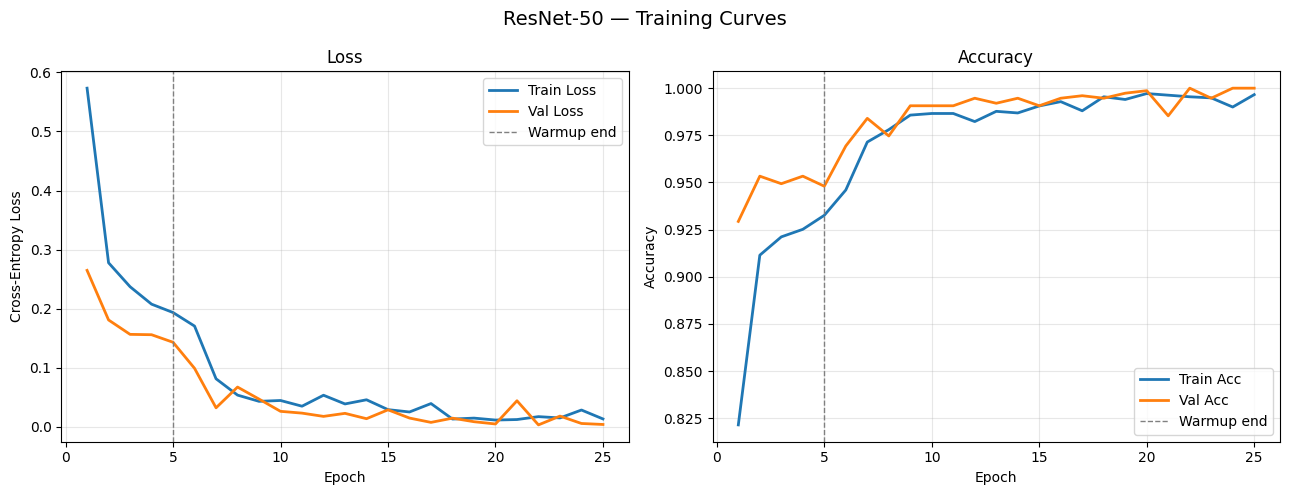

Figure saved to /content/drive/MyDrive/lung-colon-cancer-histopathology/figures/05_resnet50_training_curves.png


In [9]:
# ── Cell 9: Plot Training Curves ──────────────────────────────────────────────

epochs_ran = range(1, len(history['train_loss']) + 1)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('ResNet-50 — Training Curves', fontsize=14)

axes[0].plot(epochs_ran, history['train_loss'], label='Train Loss', linewidth=2)
axes[0].plot(epochs_ran, history['val_loss'],   label='Val Loss',   linewidth=2)
axes[0].axvline(x=5, color='gray', linestyle='--', linewidth=1, label='Warmup end')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Cross-Entropy Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs_ran, history['train_acc'], label='Train Acc', linewidth=2)
axes[1].plot(epochs_ran, history['val_acc'],   label='Val Acc',   linewidth=2)
axes[1].axvline(x=5, color='gray', linestyle='--', linewidth=1, label='Warmup end')
axes[1].set_title('Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
save_path = FIGURES_DIR / '05_resnet50_training_curves.png'
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Figure saved to {save_path}')

In [10]:
# ── Cell 10: Test Set Evaluation ──────────────────────────────────────────────

model.eval()
all_labels, all_preds, all_probs = [], [], []
softmax = nn.Softmax(dim=1)

with torch.no_grad():
    for images, labels in test_loader:
        images  = images.to(DEVICE)
        outputs = model(images)
        probs   = softmax(outputs).cpu().numpy()
        preds   = outputs.argmax(1).cpu().numpy()
        all_labels.extend(labels.numpy())
        all_preds.extend(preds)
        all_probs.extend(probs)

y_true = np.array(all_labels)
y_pred = np.array(all_preds)
y_prob = np.array(all_probs)

accuracy  = accuracy_score(y_true, y_pred)
macro_f1  = f1_score(y_true, y_pred, average='macro')
y_bin     = label_binarize(y_true, classes=list(range(5)))
macro_auc = roc_auc_score(y_bin, y_prob, multi_class='ovr', average='macro')

cm = confusion_matrix(y_true, y_pred)
per_class = {}
for i, name in enumerate(CLASS_NAMES):
    tp = cm[i, i]
    fn = cm[i, :].sum() - tp
    fp = cm[:, i].sum() - tp
    tn = cm.sum() - tp - fn - fp
    per_class[name] = {
        'sensitivity': round(tp / (tp + fn), 4) if (tp + fn) > 0 else 0,
        'specificity': round(tn / (tn + fp), 4) if (tn + fp) > 0 else 0,
    }

print('=' * 55)
print('  RESNET-50 — TEST SET RESULTS')
print('=' * 55)
print(f'  Accuracy  : {accuracy:.4f}')
print(f'  Macro F1  : {macro_f1:.4f}')
print(f'  Macro AUC : {macro_auc:.4f}')
print('=' * 55)
for name, vals in per_class.items():
    print(f'  {name:<15} Sens: {vals["sensitivity"]:.4f}  Spec: {vals["specificity"]:.4f}')
print('=' * 55)

  RESNET-50 — TEST SET RESULTS
  Accuracy  : 0.9987
  Macro F1  : 0.9987
  Macro AUC : 1.0000
  colon_aca       Sens: 1.0000  Spec: 1.0000
  colon_n         Sens: 1.0000  Spec: 1.0000
  lung_aca        Sens: 0.9933  Spec: 1.0000
  lung_n          Sens: 1.0000  Spec: 1.0000
  lung_scc        Sens: 1.0000  Spec: 0.9983


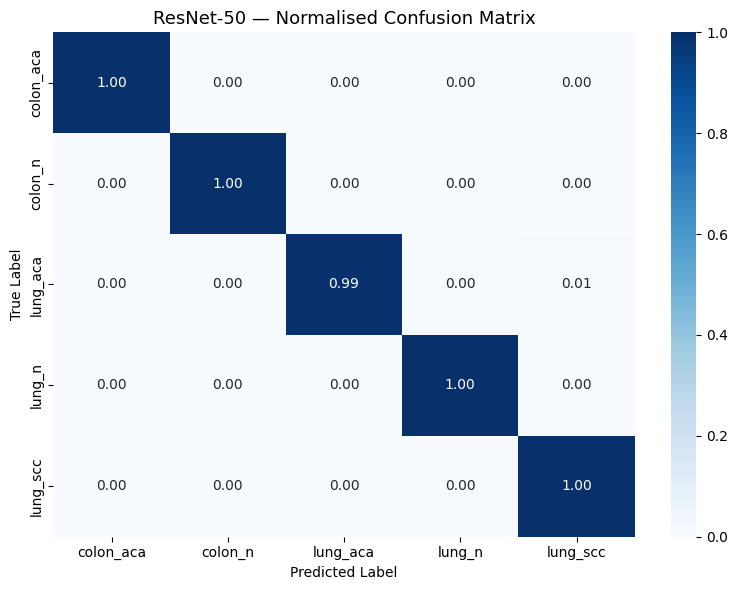

Figure saved to /content/drive/MyDrive/lung-colon-cancer-histopathology/figures/05_resnet50_confusion_matrix.png


In [11]:
# ── Cell 11: Confusion Matrix ─────────────────────────────────────────────────

cm_norm = confusion_matrix(y_true, y_pred, normalize='true')
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)
ax.set_title('ResNet-50 — Normalised Confusion Matrix', fontsize=13)
ax.set_xlabel('Predicted Label')
ax.set_ylabel('True Label')
plt.tight_layout()
save_path = FIGURES_DIR / '05_resnet50_confusion_matrix.png'
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Figure saved to {save_path}')

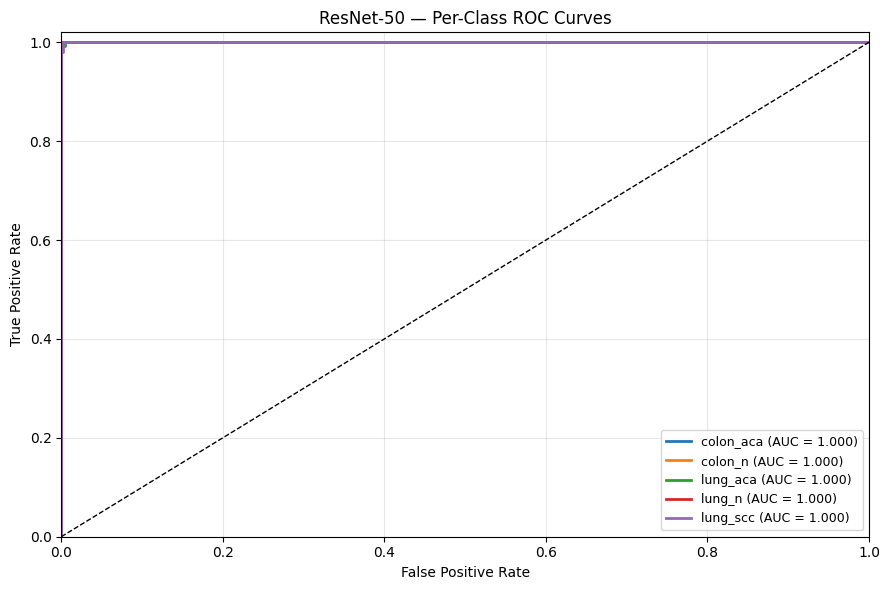

Figure saved to /content/drive/MyDrive/lung-colon-cancer-histopathology/figures/05_resnet50_roc_curves.png


In [12]:
# ── Cell 12: ROC Curves ───────────────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(9, 6))
colors = plt.cm.tab10.colors
for i, name in enumerate(CLASS_NAMES):
    fpr, tpr, _ = roc_curve(y_bin[:, i], y_prob[:, i])
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=colors[i], linewidth=2,
            label=f'{name} (AUC = {roc_auc:.3f})')
ax.plot([0, 1], [0, 1], 'k--', linewidth=1)
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.02])
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ResNet-50 — Per-Class ROC Curves')
ax.legend(loc='lower right', fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
save_path = FIGURES_DIR / '05_resnet50_roc_curves.png'
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Figure saved to {save_path}')

In [13]:
# ── Cell 13: Overfitting Analysis and Save Results ────────────────────────────

final_train_acc = history['train_acc'][-1]
gap = final_train_acc - accuracy

print('=' * 55)
print('  RESNET-50 — OVERFITTING ANALYSIS')
print('=' * 55)
print(f'  Final Train Accuracy : {final_train_acc:.4f}')
print(f'  Test Accuracy        : {accuracy:.4f}')
print(f'  Gap                  : {gap:.4f}')
print(f'  Status               : {"WARNING — gap > 5%" if gap > 0.05 else "OK"}')
print('=' * 55)

results = {
    'model'     : 'ResNet-50',
    'accuracy'  : round(accuracy, 4),
    'macro_f1'  : round(macro_f1, 4),
    'macro_auc' : round(macro_auc, 4),
    'train_acc' : round(final_train_acc, 4),
    'gap'       : round(gap, 4),
    'per_class' : per_class,
}
with open(MODELS_DIR / 'resnet50_results.json', 'w') as f:
    json.dump(results, f, indent=2)
print('Results saved to Drive.')

  RESNET-50 — OVERFITTING ANALYSIS
  Final Train Accuracy : 0.9966
  Test Accuracy        : 0.9987
  Gap                  : -0.0021
  Status               : OK
Results saved to Drive.


In [14]:
# ── Cell 14: Three-Model Comparison Table ─────────────────────────────────────

results_files = {
    'Baseline CNN'   : MODELS_DIR / 'baseline_cnn_results.json',
    'EfficientNet-B0': MODELS_DIR / 'efficientnet_b0_results.json',
    'ResNet-50'      : MODELS_DIR / 'resnet50_results.json',
}

rows = []
for model_name, path in results_files.items():
    if path.exists():
        with open(path) as f:
            r = json.load(f)
        rows.append({
            'Model'     : model_name,
            'Accuracy'  : r['accuracy'],
            'Macro F1'  : r['macro_f1'],
            'Macro AUC' : r['macro_auc'],
            'Train Acc' : r['train_acc'],
            'Gap'       : r['gap'],
        })
    else:
        print(f'WARNING: Results file not found for {model_name}: {path}')

comparison_df = pd.DataFrame(rows)
print('\n=== Three-Model Comparison ===')
print(comparison_df.to_string(index=False))

best_idx   = comparison_df['Macro AUC'].idxmax()
best_model = comparison_df.loc[best_idx, 'Model']
print(f'\nBest model by AUC-ROC : {best_model}')
print('This model will be used for Grad-CAM analysis in Notebook 06.')


=== Three-Model Comparison ===
          Model  Accuracy  Macro F1  Macro AUC  Train Acc     Gap
   Baseline CNN    0.6853    0.6617     0.9386     0.5877 -0.0976
EfficientNet-B0    0.9933    0.9933     0.9999     0.9974  0.0041
      ResNet-50    0.9987    0.9987     1.0000     0.9966 -0.0021

Best model by AUC-ROC : ResNet-50
This model will be used for Grad-CAM analysis in Notebook 06.


In [15]:
# ── Cell 15: Save Notebook to Drive ──────────────────────────────────────────

try:
    shutil.copy('/content/05_resnet50.ipynb',
                str(BASE_DIR / 'notebooks' / '05_resnet50.ipynb'))
    print('Notebook saved to Drive.')
except:
    print('Use File > Save a copy in Drive to save this notebook.')

Use File > Save a copy in Drive to save this notebook.
